In [5]:
!pip install Sastrawi emoji

In [6]:
import pandas as pd
import numpy as np
import json
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import emoji

In [7]:
file_path = "data_untuk_modeling.csv"

#### Preprocessing Text

In [8]:
df = pd.read_csv(file_path)
df.columns.tolist()

['Unnamed: 0',
 'Judul',
 'Industri',
 'Tipe',
 'Kategori',
 'Kota',
 'Provinsi',
 'Negara',
 'Gaji_Min',
 'Gaji_Max',
 'Skills',
 'Pengalaman_Bulan',
 'Pendidikan',
 'Deskripsi']

In [9]:
# mengecek kolom kosong
df.isnull().sum()

,0
Unnamed: 0,0
Judul,0
Industri,0
Tipe,0
Kategori,0
Kota,0
Provinsi,0
Negara,0
Gaji_Min,0
Gaji_Max,0


In [10]:
df.head(3)

,Unnamed: 0,Judul,Industri,Tipe,Kategori,Kota,Provinsi,Negara,Gaji_Min,Gaji_Max,Skills,Pengalaman_Bulan,Pendidikan,Deskripsi
0,0,IT Business Analyst,Information Technology and Services,FULL_TIME,System Analyst,Jakarta Timur,DKI Jakarta,ID,Tidak ada,Tidak ada,"SQL, Business Analysis, Relational Databases, ...",36.0,bachelor degree,Job description \r\n \r\n Evaluating and docum...
1,1,IT System Analyst,Information Technology and Services,FULL_TIME,System Analyst,Surabaya,Jawa Timur,ID,7000000.0,9000000.0,"Requirements Analysis, SQL, Business Analysis,...",12.0,bachelor degree,General Qualification : \r\n \r\n Man (23 - 35...
2,2,IT Business Analyst - Insurance exp,Information Technology and Services,CONTRACTOR,Business Analyst,Jakarta Selatan,DKI Jakarta,ID,13000000.0,14500000.0,"SDLC, Life Insurance, Teamwork, Business Proce...",36.0,bachelor degree,Skill And Experience : \r\n - Understand the B...


In [11]:
df['text_gabungan'] = (
    # "judul: " + df['Judul'].fillna('') + " " +
    "industri: " + df['Industri'].fillna('') + " " +
    "kategori: " + df['Kategori'].fillna('') + " " +
    "pendidikan: " + df['Pendidikan'].fillna('') + " " +
    "tipe: " + df['Tipe'].fillna('') + " " +
    "lokasi: " + (df['Kota'].fillna('') + " " + df['Provinsi'].fillna('')) + " " +
    "skills: " + df['Skills'].fillna('') + " " +
    "deskripsi: " + df['Deskripsi'].fillna('')
)

print(df['text_gabungan'][0])

industri: Information Technology and Services kategori: System Analyst pendidikan: bachelor degree tipe: FULL_TIME lokasi: Jakarta Timur DKI Jakarta skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC deskripsi: Job description 
 
 Evaluating and documenting business processes, anticipating requirements, uncovering areas for improvement, and developing and implementing solutions. 
 Conducting meetings and presentations to share ideas and findings. 
 Performing requirements analysis. 
 Working closely with clients, technical/programer, and project manager 
 Create Business Requirement documents and Functional Specification Document 
 
 
 Qualification 
 Minimum Bachelor’s Degree in Business ot  IT from reputable university 
 
 Minimum 2 (two) year experience as Business Analyst or Functional Analyst 
 Having good knowledge of Software Development Life Cycle  (SDLC) 
 Excellent documentation skills. 
 Excellent analytical, judgment and problem s

##### Cleaning

In [12]:

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)                 # HTML
    text = re.sub(r'[^a-z0-9\s:/_\-\+\.]', ' ', text) # keep tanda penting
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_gabungan'] = df['text_gabungan'].apply(basic_clean)
print(df['text_gabungan'][0])

industri: information technology and services kategori: system analyst pendidikan: bachelor degree tipe: full_time lokasi: jakarta timur dki jakarta skills: sql business analysis relational databases system analysis analytical skills sdlc deskripsi: job description evaluating and documenting business processes anticipating requirements uncovering areas for improvement and developing and implementing solutions. conducting meetings and presentations to share ideas and findings. performing requirements analysis. working closely with clients technical/programer and project manager create business requirement documents and functional specification document qualification minimum bachelor s degree in business ot it from reputable university minimum 2 two year experience as business analyst or functional analyst having good knowledge of software development life cycle sdlc excellent documentation skills. excellent analytical judgment and problem solving skills high quality analysis including b

##### Case Folding

In [13]:
def case_folding(text):
    text = text.lower()
    return text

df["text_gabungan"] = df["text_gabungan"].apply(case_folding)
print(df["text_gabungan"][1])

industri: information technology and services kategori: system analyst pendidikan: bachelor degree tipe: full_time lokasi: surabaya jawa timur skills: requirements analysis sql business analysis sdlc stakeholder management cloud platform system teamwork system analysis deskripsi: general qualification : man 23 - 35 years old education min. s1 information technology/information system/computer system minimum 1-3 years of experience in it coordination business partnering or similar roles. strong understanding of it service management project management and technology roadmaps. strong communication collaboration and stakeholder management skills. fluent in bahasa indonesia and english written and spoken . will to work located in surabaya specific qualification : sql query/tuning basic programming language laravel basic understand client-server and networking concept basic it service management knowledge basic familiar with report development ssrs powerbi will be a plus basic good document

##### Normalization

In [14]:
# df_normalisasi = pd.read_csv("colloquial-indonesian-lexicon-normalisasi.csv")
# df_normalisasi = df_normalisasi[["slang", "formal"]]
# df_normalisasi.head()

In [15]:
# normalization_dict = dict(zip(df_normalisasi['slang'], df_normalisasi['formal']))
# normalization_dict.pop('it')

# def normalization(text):
#     words = text.split()
#     words = [normalization_dict.get(word, word) for word in words]
#     return ' '.join(words)

# df['text_gabungan'] = df["text_gabungan"].apply(normalization)
# print(df['text_gabungan'][1])

##### Stopword Removal

In [16]:
# tidak relevan untuk kasus INDO ENGLISH, karena banyak kata yang sudah baku dan tidak ada slang yang perlu dinormalisasi dan Stopword

#### Membangun Modeling dengan Pseudo-CV

#### Membangun Data Pseudo-CV

In [17]:
df['pseudo_cv'] = (
    # "judul: " + df['Judul'].fillna('') + " " +
    "industri: " + df['Industri'].fillna('') + " " +
    "kategori: " + df['Kategori'].fillna('') + " " +
    "pendidikan: " + df['Pendidikan'].fillna('') + " " +
    "tipe: " + df['Tipe'].fillna('') + " " +
    "skills: " + df['Skills'].fillna('') + " "
)
print(df['pseudo_cv'][0])

industri: Information Technology and Services kategori: System Analyst pendidikan: bachelor degree tipe: FULL_TIME skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC 


Rata-rata panjang kata : 180 kata
80% data berada di bawah: 253 kata
90% data berada di bawah: 299 kata
95% data berada di bawah: 345 kata
Panjang kata maksimum  : 1098 kata


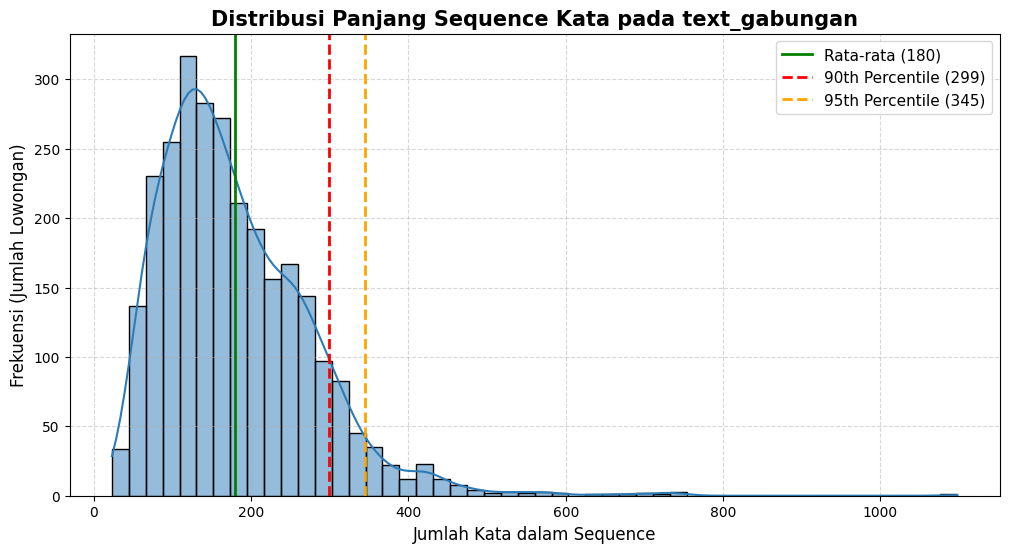

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Menghitung jumlah kata (panjang sequence) untuk setiap baris di text_gabungan
# Pastikan teks sudah melalui tahap basic_clean / case_folding
df['seq_length'] = df['text_gabungan'].apply(lambda x: len(str(x).split()))

# 2. Menghitung statistik deskriptif dan persentil
panjang_rata2 = df['seq_length'].mean()
persentil_80 = np.percentile(df['seq_length'], 80)
persentil_90 = np.percentile(df['seq_length'], 90)
persentil_95 = np.percentile(df['seq_length'], 95)
max_length = df['seq_length'].max()

print(f"Rata-rata panjang kata : {panjang_rata2:.0f} kata")
print(f"80% data berada di bawah: {persentil_80:.0f} kata")
print(f"90% data berada di bawah: {persentil_90:.0f} kata")
print(f"95% data berada di bawah: {persentil_95:.0f} kata")
print(f"Panjang kata maksimum  : {max_length} kata")

# 3. Membuat Plot Distribusi
plt.figure(figsize=(12, 6))
sns.histplot(df['seq_length'], bins=50, kde=True, color='#2c7bb6')

# Menambahkan garis vertikal untuk persentil sebagai panduan penentuan MAX_LEN
plt.axvline(panjang_rata2, color='green', linestyle='-', linewidth=2, label=f'Rata-rata ({panjang_rata2:.0f})')
plt.axvline(persentil_90, color='red', linestyle='--', linewidth=2, label=f'90th Percentile ({persentil_90:.0f})')
plt.axvline(persentil_95, color='orange', linestyle='--', linewidth=2, label=f'95th Percentile ({persentil_95:.0f})')

# Kustomisasi tampilan plot
plt.title('Distribusi Panjang Sequence Kata pada text_gabungan', fontsize=15, fontweight='bold')
plt.xlabel('Jumlah Kata dalam Sequence', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Lowongan)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [19]:
df['seq_length'].describe()

,seq_length
count,2761.000000
mean,179.815284
std,95.879423
min,23.000000
25%,111.000000
50%,161.000000
75%,235.000000
max,1098.000000


#### Inferens

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dot, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
cv_texts = []
job_texts = []
labels = []

# Data Positif (Cocok = 1) -> pseudo_cv dipasangkan dengan job aslinya
for i in range(len(df)):
    cv_texts.append(df['pseudo_cv'].iloc[i])
    job_texts.append(df['text_gabungan'].iloc[i])
    labels.append(1)

# Data Negatif (Tidak Cocok = 0) -> pseudo_cv dipasangkan dengan job random
# Ini penting agar model LSTM tidak sekadar menebak "1" terus menerus
for i in range(len(df)):
    random_idx = np.random.choice([x for x in range(len(df)) if x != i])
    cv_texts.append(df['pseudo_cv'].iloc[i])
    job_texts.append(df['text_gabungan'].iloc[random_idx])
    labels.append(0)

# Convert ke numpy array
labels = np.array(labels)

In [22]:
MAX_VOCAB = 12000
# masih perlu diteliti lebih lanjut
MAX_LEN = 299

In [23]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
# Fit tokenizer ke semua teks (CV + Job)
tokenizer.fit_on_texts(cv_texts + job_texts)

# Convert teks ke sequence angka dan lakukan padding
cv_seq = pad_sequences(tokenizer.texts_to_sequences(cv_texts), maxlen=MAX_LEN, padding='post')
job_seq = pad_sequences(tokenizer.texts_to_sequences(job_texts), maxlen=MAX_LEN, padding='post')

In [24]:
from sklearn.model_selection import train_test_split

X_cv_train, X_cv_test, X_job_train, X_job_test, y_train, y_test = train_test_split(
    cv_seq,
    job_seq,
    labels,
    test_size=0.15,
    random_state=42
)

print(f"Total data Train (termasuk Validation nanti): {len(y_train)}")
print(f"Total data Test murni: {len(y_test)}")

Total data Train (termasuk Validation nanti): 4693
Total data Test murni: 829


In [25]:
# 3. MEMBANGUN ARSITEKTUR CUSTOM LAYER (Siamese BiLSTM)
embedding_dim = 64

In [26]:
# Input Layers
cv_input = Input(shape=(MAX_LEN,), name="cv_input")
job_input = Input(shape=(MAX_LEN,), name="job_input")

# Embedding Layer (Dibagi / Share weights untuk kedua input)
shared_embedding = Embedding(input_dim=MAX_VOCAB, output_dim=embedding_dim, name="shared_embedding")

# BiLSTM Layer (Dibagi / Share weights untuk kedua input)
shared_bilstm = Bidirectional(LSTM(64, return_sequences=False), name="shared_bilstm")

cv_emb = shared_embedding(cv_input)
job_emb = shared_embedding(job_input)

cv_vector = shared_bilstm(cv_emb)
job_vector = shared_bilstm(job_emb)

In [27]:
# Gabungkan vektor CV dan Job secara bersisian
merged_vector = Concatenate(axis=-1, name="gabungan_vektor")([cv_vector, job_vector])

# Tambahkan sedikit layer Dense (otak tambahan) untuk mempelajari pola gabungan tersebut
dense_layer = Dense(32, activation='relu')(merged_vector)

# Output final menggunakan Sigmoid agar nilainya terkurung di 0.0 sampai 1.0
output_layer = Dense(1, activation='sigmoid', name="prediksi_final")(dense_layer)

# Bungkus menjadi model
model = Model(inputs=[cv_input, job_input], outputs=output_layer)

# 2. PERBAIKAN LOSS FUNCTION
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # <-- Ganti ke sini
    metrics=['accuracy', 'mae'] # Bisa pantau akurasi sekaligus MAE
)

In [28]:
import tensorflow as tf

class JobRecommendationCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0

    def on_train_begin(self, logs=None):
        print("\n=== Training Sistem Rekomendasi Lowongan Dimulai ===")

    def on_epoch_end(self, epoch, logs=None):
        train_acc = logs.get("accuracy")
        val_acc = logs.get("val_accuracy")
        train_loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        print(
            f"\nEpoch {epoch+1}"
            f" | Train Acc: {train_acc:.4f}"
            f" | Val Acc: {val_acc:.4f}"
            f" | Train Loss: {train_loss:.4f}"
            f" | Val Loss: {val_loss:.4f}"
        )

        if val_acc > self.best_val_accuracy:
            self.best_val_accuracy = val_acc
            self.model.save("model_hasil/model_terbaik.keras")

            print(
                f"Model terbaik baru ditemukan "
                f"(val_accuracy={val_acc:.4f})"
            )

        if (train_acc - val_acc) > 0.10:
            print(
                "Indikasi overfitting: "
                "akurasi training jauh lebih tinggi daripada validasi."
            )

    def on_train_end(self, logs=None):
        print("\n=== Training Selesai ===")
        print(
            f"Best Validation Accuracy: "
            f"{self.best_val_accuracy:.4f}"
        )

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

custom_callback = JobRecommendationCallback()

history = model.fit(
    x=[X_cv_train, X_job_train],
    y=y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        early_stop,
        custom_callback
    ]
)


=== Training Sistem Rekomendasi Lowongan Dimulai ===
Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5343 - loss: 0.6921 - mae: 0.4978
Epoch 1 | Train Acc: 0.5711 | Val Acc: 0.7529 | Train Loss: 0.6774 | Val Loss: 0.5659
Model terbaik baru ditemukan (val_accuracy=0.7529)
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.5711 - loss: 0.6774 - mae: 0.4895 - val_accuracy: 0.7529 - val_loss: 0.5659 - val_mae: 0.4157
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8099 - loss: 0.4626 - mae: 0.3328
Epoch 2 | Train Acc: 0.8356 | Val Acc: 0.8626 | Train Loss: 0.4161 | Val Loss: 0.3476
Model terbaik baru ditemukan (val_accuracy=0.8626)
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8356 - loss: 0.4161 - mae: 0.2947 - val_accuracy: 0.8626 - val_loss: 0.3476 - val_mae: 0.2305
Epoch 3/20
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8874 - loss: 0.2957 - mae: 0.2037
Epoch 3 | Train Acc: 0.8990 | Val Acc: 0.8775 | Train Loss: 0.2787 |

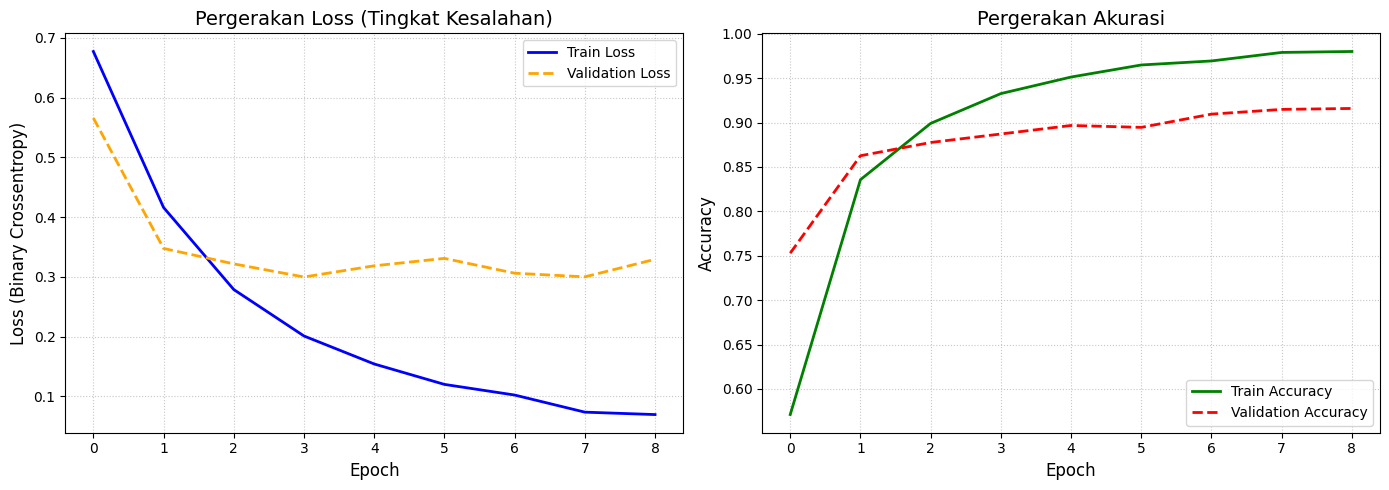

In [30]:
import matplotlib.pyplot as plt

# Mengatur ukuran kanvas grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Grafik Pergerakan Loss ---
ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title('Pergerakan Loss (Tingkat Kesalahan)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.7)

# --- 2. Grafik Pergerakan Akurasi ---
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
ax2.set_title('Pergerakan Akurasi', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

Sedang melakukan prediksi pada data testing...
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

          CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Tidak Cocok (0)       0.96      0.81      0.88       406
      Cocok (1)       0.84      0.97      0.90       423

       accuracy                           0.89       829
      macro avg       0.90      0.89      0.89       829
   weighted avg       0.90      0.89      0.89       829



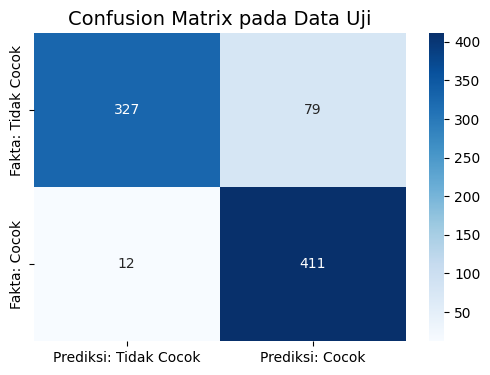

In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lakukan prediksi menggunakan data testing
print("Sedang melakukan prediksi pada data testing...")
y_pred_prob = model.predict([X_cv_test, X_job_test])

# 2. Ubah probabilitas menjadi label kelas (0 atau 1) dengan threshold 0.5
# Jika probabilitas > 0.5, maka True (1), jika tidak maka False (0)
y_pred_classes = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Tampilkan Classification Report
print("\n" + "="*40)
print("          CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_classes, target_names=['Tidak Cocok (0)', 'Cocok (1)']))

# 4. (Opsional) Tampilkan Confusion Matrix agar lebih visual
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi: Tidak Cocok', 'Prediksi: Cocok'],
            yticklabels=['Fakta: Tidak Cocok', 'Fakta: Cocok'])
plt.title('Confusion Matrix pada Data Uji', fontsize=14)
plt.show()

In [32]:
# Menghitung kemiripan (Dot Product sering dipakai untuk mengukur similarity di neural network)
# similarity = Dot(axes=1, normalize=True, name="cosine_similarity")([cv_vector, job_vector])

# # Gabungkan menjadi satu model
# model = Model(inputs=[cv_input, job_input], outputs=similarity)

# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.summary()

In [33]:
#

In [34]:
import pickle

# Tentukan path penyimpanan di Google Drive kamu
# Menggunakan folder yang sama dengan tempat dataset kamu berada

# save_path = '/content/drive/MyDrive/Dataset_codingcamp_loker/'
save_path = './model_hasil/'

# 1. Menyimpan Model Keras
# Menggunakan format .keras yang merupakan standar terbaru dan terefisien dari TensorFlow
model.save(save_path + 'model_rekomendasi_3.keras')

# 2. Menyimpan Tokenizer menggunakan Pickle
with open(save_path + 'tokenizer_loker3.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# print("Model dan Tokenizer berhasil disimpan dengan aman di Google Drive!")

In [35]:
# print("\n=== Evaluasi pada Data Test Murni ===")
# eval_results = model.evaluate(x=[X_cv_test, X_job_test], y=y_test)

# print(f"Loss pada Data Test: {eval_results[0]:.4f}")
# print(f"MAE pada Data Test: {eval_results[1]:.4f}")

In [36]:
# contoh pesudo cv
print("Contoh Pseudo CV untuk User:")
print(df['pseudo_cv'][0])

Contoh Pseudo CV untuk User:
industri: Information Technology and Services kategori: System Analyst pendidikan: bachelor degree tipe: FULL_TIME skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC 


In [37]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Asumsi:
# 1. 'model' sudah di-load atau masih ada di memori.
# 2. 'tokenizer' sudah di-load.
# 3. 'df_raw' adalah dataframe aslimu yang berisi semua lowongan.

# 1. Teks CV dari User (Bisa didapat dari input form)
text_cv_user = "Information Technology and Services kategori: System Analyst pendidikan: bachelor degree tipe: FULL_TIME skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC "

# 2. Siapkan semua teks lowongan kerja dari database (menggunakan text_gabungan)
semua_teks_lowongan = df['text_gabungan'].tolist()
jumlah_lowongan = len(semua_teks_lowongan)

# 3. Gandakan teks CV user agar jumlahnya sama dengan jumlah lowongan
# Ini menciptakan pasangan (CV User, Job 1), (CV User, Job 2), dst...
teks_cv_digandakan = [text_cv_user] * jumlah_lowongan

# 4. Tokenisasi dan Padding
seq_cv_infer = pad_sequences(tokenizer.texts_to_sequences(teks_cv_digandakan), maxlen=MAX_LEN, padding='post')
seq_job_infer = pad_sequences(tokenizer.texts_to_sequences(semua_teks_lowongan), maxlen=MAX_LEN, padding='post')

# 5. Lakukan Prediksi (Mencari skor kecocokan untuk semua pasangan)
print("Sedang mencocokkan CV dengan semua lowongan...")
prediksi_model = model.predict([seq_cv_infer, seq_job_infer])
prediksi_model = prediksi_model.flatten() # Ratakan ke 1D agar mudah digabung dengan skor TF-IDF

tfidf = TfidfVectorizer(max_features=MAX_VOCAB, ngram_range=(1,2))
judul_lowongan = df['Judul'].tolist() + ["Backend Developer"]
tfidf_matrix = tfidf.fit_transform(judul_lowongan)

prediksi_tfidf = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()

skor_prediksi = (0.5 * prediksi_model) + (0.5 * prediksi_tfidf) # Gabungkan skor model dan TF-IDF dengan bobot 50:50

# 6. Mengurutkan hasil dari skor tertinggi ke terendah
# argsort mengembalikan index. '[::-1]' digunakan untuk membalik urutan agar yang terbesar di awal.
index_terbaik = np.argsort(skor_prediksi)[::-1]

# 7. Tampilkan Top 5 Rekomendasi Teratas
top_n = 10
print(f"\n=== TOP {top_n} REKOMENDASI LOWONGAN KERJA ===")

for i in range(top_n):
    idx = index_terbaik[i]
    skor = skor_prediksi[idx]

    # Hanya tampilkan jika skornya di atas threshold (misal > 0.5)
    if skor > 0.5:
        print(f"\nRekomendasi #{i+1} (Skor Kecocokan: {skor:.4f})")
        # Mengambil data dari raw dataframe berdasarkan index
        print(f"Judul    : {df.loc[idx, 'Judul']}")
        print(f"Perusahaan: {df.loc[idx, 'Industri']}") # Ganti dengan kolom yang sesuai
        print(f"Lokasi   : {df.loc[idx, 'Kota']}")
    else:
        print(f"\nRekomendasi #{i+1}: Tidak ada lagi lowongan yang dianggap cocok (Skor < 0.5)")
        break

Sedang mencocokkan CV dengan semua lowongan...
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

=== TOP 10 REKOMENDASI LOWONGAN KERJA ===

Rekomendasi #1 (Skor Kecocokan: 0.9503)
Judul    : Backend Developer
Perusahaan: Management Consulting
Lokasi   : Bekasi

Rekomendasi #2 (Skor Kecocokan: 0.9294)
Judul    : Backend Developer
Perusahaan: Human Resources
Lokasi   : Tangerang Selatan

Rekomendasi #3 (Skor Kecocokan: 0.9138)
Judul    : Backend Developer
Perusahaan: Computer Software
Lokasi   : Tangerang

Rekomendasi #4 (Skor Kecocokan: 0.8888)
Judul    : Backend Developer
Perusahaan: Computer & Network Security
Lokasi   : Jakarta Selatan

Rekomendasi #5 (Skor Kecocokan: 0.8857)
Judul    : backend developer
Perusahaan: Computer Software
Lokasi   : Jakarta Utara

Rekomendasi #6 (Skor Kecocokan: 0.7861)
Judul    : Backend Developer Intern
Perusahaan: Information Technology and Services
Lokasi   : Jakarta Selatan

Rekomendasi #7 (Skor Kecocokan: 0.7806)
Judul    : Senior Backend Developer
Perusahaa